<a href="https://colab.research.google.com/github/fathanick/Fundamentals-of-Data-Science/blob/main/Naive%20Bayes/01_Spam_Classification_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Import Needed Libraries

In [1]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing (NLP)
import string
import nltk
from nltk.corpus import stopwords

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download NLTK stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Step 2: Data Loading

Instead of downloading a file manually, we can load the dataset directly from a public URL into a Pandas DataFrame.

In [2]:
# Load the dataset from a public repository
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# Display the first 5 rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


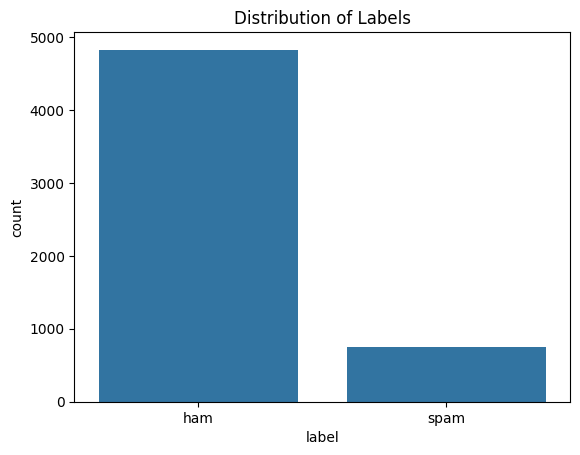

In [10]:
sns.countplot(x='label', data=df)
plt.title('Distribution of Labels')
plt.show()

## Step 3: Data Preprocessing

In [3]:
def preprocess_text(text):
    # Remove punctuation
    remove_punc = [char for char in text if char not in string.punctuation]
    remove_punc = ''.join(remove_punc)

    # Convert to lowercase and remove stopwords
    cleaned_words = [word.lower() for word in remove_punc.split() if word.lower() not in stopwords.words('english')]

    return ' '.join(cleaned_words)

In [5]:
# Apply preprocessing to the message column
df['cleaned_message'] = df['message'].apply(preprocess_text)

In [6]:
# Preview the changes
df[['message', 'cleaned_message']].head()

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## Step 4: Feature Extraction (Vectorization)

Computers don't understand text; they understand numbers. We use CountVectorizer (Tokenization/Bag of Words) to convert our text sentences into a matrix of token counts.

In [7]:
# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Transform the cleaned messages into numerical vectors (X)
X = vectorizer.fit_transform(df['cleaned_message'])

# Target variable (y)
y = df['label']

## Step 5: Data Splitting

We need to split our data into a training set (to teach the model) and a testing set (to see how well it learned). We will use an 80/20 split.

In [8]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 4457
Testing samples: 1115


## Step 6: Classification (Model Training)

In [9]:
# Initialize the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


## Step 7: Evaluation

Now, let's see how well our model performs by making predictions on the test data and plotting a Confusion Matrix.

In [11]:
# Make predictions on the test set
y_pred = nb_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 97.49%

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       966
        spam       0.88      0.95      0.91       149

    accuracy                           0.97      1115
   macro avg       0.93      0.96      0.95      1115
weighted avg       0.98      0.97      0.98      1115



### Visualizing the Results
To clearly see the True Positives, False Positives, True Negatives, and False Negatives, let's plot a heatmap of the confusion matrix.

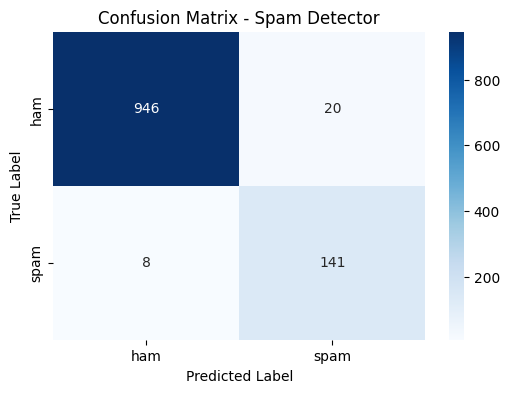

In [12]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

# Plotting using Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix - Spam Detector')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Step 8: Inference (Prediction New Data)

In [13]:
def predict_message(custom_message):
    # 1. Preprocess the incoming message
    cleaned = preprocess_text(custom_message)
    # 2. Vectorize using the same vectorizer from Step 4
    vectorized = vectorizer.transform([cleaned])
    # 3. Predict
    prediction = nb_model.predict(vectorized)
    return prediction[0]

In [27]:
user_message = "" #@param {type:"string"}

if user_message is None or user_message.strip() == "":
  print("Please enter a valid message.")
else:
  result = predict_message(user_message)
  print(f"Prediction: {result}")

Please enter a valid message.
